![Wine plot](wine.jpg)

***
## PART 4
***
# Bayesian optimization in action

In the last part of this lab, we will use Bayesian optimization to optimize the hyperparameters of various machine learning models. In **part 3**, the goal was to get a deeper understanding of how the Bayesian Optimization works internally. Now, we are looking to build something ready for practice, and so, we will switch over and use a professional implementation. Here we will use the [BoTorch](https://botorch.org/) library developed at Meta, which is arguably the most efficient and well maintained library at the moment. It uses the [Gpytorch](https://gpytorch.ai/) gaussian process library developed at Cornell University.

The black-box models are training on the white wine and red wine datasets, which contains ~5.000 different wines with physical attributes and a taste score from users that goes from 1 to 10. The data comes from the paper

P. Cortez, A. Cerdeira, F. Almeida, T. Matos and J. Reis.
Modeling wine preferences by data mining from physicochemical properties.
In Decision Support Systems, Elsevier, 47(4):547-553. ISSN: 0167-9236.

In [blackbox_problems.py](./blackbox_problems.py), we define a SVM regressor on taste score, an SVM classifier between red and white wines, an ANN regressor on taste as well as a GBT on taste. Each problem has a different parameter space (some parameters are continuous, others discrete). For continuous parameters, the models are made to take inputs in the range 0 to 1. For discrete parameters, they list the potential options.

Now, go to [blackbox_problems.py](./blackbox_problems.py), and make sure that you understand how the black box functions are built up.


## Setting up

In [2]:
%pip install torch scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 21.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 20.2 MB/s eta 0:00:00

[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: pip3.11 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import torch
from matplotlib import pyplot as plt
import numpy as np
from blackbox_problems import Branin, ANNWineQuality, SVMClassifierWineType, GradientBoostingWineQuality, BlackBoxBase

torch.manual_seed(0);

In [7]:
# Selecting the appropriate training device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device {device}")

Using device cpu


### Testing the the black box functions

In [8]:
blackbox = ANNWineQuality(100)
default_performance = blackbox(torch.tensor([0, 0,  0, 0, 0], dtype=torch.double, device=device))
print("test loss of default hyperparameters:", default_performance.item())

test loss of default hyperparameters: 41.061499119265335


### Defining the GP model

Ok, now we have a number of black box functions to optimize. Before we get cooking, let's take a step back and think through what we are doing.

**Questions**:
- What is our target metric?
- What variables are we optimizing over?
- How does this relate to classic training?

**Answers:**
- The number the blackbox-function returns.
- Input vector, i.e x, i.e the model hyperparams
- It's like classic training but changing hyperparams after each iteration to get a better result.


YOUR TASK: Your task now is to create a BO loop to optimize the different functions. For this you will need:
- The blackbox problem
- Some initial random sampled data
- A GP
- Someway to fit the hyperparameters of the GP
- An acquisition function
- An acquisition function optimizer

We model the GP with GPyTorch, and use BoTorch for the B specific routines. Between the two of them, you will have most of the things that you need.


#### Tips and tricks and notes
- We recommend using d+1 randomly sampled points as initial training data for the GP before starting to generate new points with BO.
- The "best" acquisition function for basic BO is Expected Improvement, and it is normally optimized using the L-BFGS algorithm (handled by gpytorch).
- All blackboxes take input in the range $[0,1]$. However, some blackboxes require discrete input for some dimensions. Those need some special treatment when optimizing the acquisition function and when random sampling the initial points.
- Make sure to standardize $y$ before feeding it to the GP.
- Note that we are now minimizing, whereas in **part 3** we were maximizing.
- BoTorch will throw some random warnings when it encounters numerical instabilities. Many of those can be ignored.

#### A cheap function
We have added Branin, which is a simple cheap synthetic problem to the blackbox functions. It is going to be easiest to start with that one to make sure everything works before testing the real problems.

In [15]:
%pip install gpytorch botorch


[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: pip3.11 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [16]:

import gpytorch
from gpytorch.likelihoods import GaussianLikelihood

from botorch.models import SingleTaskGP


def get_gp(x_train: torch.Tensor, y_train: torch.Tensor) -> SingleTaskGP:
    # ➡️ TODO : Create a new SingleTaskGP and return the model  ⬅️
    # See https://botorch.readthedocs.io/en/stable/models.html#botorch.models.gp_regression.SingleTaskGP for hints
    # You can try to improve your GP by choosing another kernel, another length scale prior, or 
    # another prior for the likelihood. The default should be fine though.
    likelihood = GaussianLikelihood()
    model = SingleTaskGP(
        train_X=x_train,
        train_Y=y_train,
        likelihood=likelihood,
    )
    return model


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Implementing the loop

In [ ]:

from botorch.exceptions import OptimizationWarning
import warnings
from botorch.optim import optimize_acqf_mixed, optimize_acqf
from botorch.acquisition import LogExpectedImprovement
from gpytorch import ExactMarginalLogLikelihood
from botorch.utils.transforms import standardize
from botorch.fit import fit_gpytorch_mll

import random

import torch


# ➡️ TODO : implement the BO loop ⬅️
# We provide some scaffolding and the acqf. optimizer
def bo_loop(
    blackbox: BlackBoxBase,
    n_iterations: int,
    *,
    verbose: bool = False,
) -> tuple[torch.Tensor, torch.Tensor]:

    n_init = blackbox.dim + 1
    n_bo_steps = n_iterations - n_init

    # ➡️ TODO : initiate x with n_init random observations ⬅️
    x = torch.rand(n_init, blackbox.dim, dtype=torch.double)
    
    # for dim_idx, options in blackbox.discrete_indices.items():
    #     options = torch.tensor(options, dtype=torch.double)
    #     sampled_idx = torch.randint(len(options), (n_init,))
    #     x[:, dim_idx] = options[sampled_idx]

    # ➡️ TODO : evaluate your bbf on x to get the initial y ⬅️
    y = torch.vstack([
        blackbox(x_i).reshape(1, 1).to(dtype=torch.double)
        for x_i in x
    ])


    # Botorch throws a lot of warnings when it fails to invert matrices.
    # Mostly, it just tries again and it works. So we hide them for now.
    warnings.filterwarnings("ignore", category=OptimizationWarning)
    warnings.filterwarnings("ignore", category=RuntimeWarning, module="botorch")


    if verbose:
        print('*** Starting Bayesian Optimization ***')
    for gp_iter in range(n_bo_steps):
        if verbose:
            print(f'** Iteration {gp_iter + 1}/{n_bo_steps} **')

        # ➡️ TODO : Standardize the y values to have mean zero and standard deviation one.
        y_stand = standardize(y)

        # ➡️ TODO : Create a new GP with the normalized x and y values
        gp = get_gp(x, y_stand)

        # Your GP model has an attribute `likelihood` which you can use to compute the marginal log likelihood.
        # This attribute gives the term p(y|f,X,l) in the marginal log likelihood which in our case
        # is a Gaussian (see https://docs.gpytorch.ai/en/stable/likelihoods.html#gaussianlikelihood )
        # ➡️ TODO : Define the marginal log likelihood of the model (see https://docs.gpytorch.ai/en/stable/marginal_log_likelihoods.html#exactmarginalloglikelihood )
        # ➡️ TODO : Train the model (see https://botorch.readthedocs.io/en/stable/fit.html)
        mll = ExactMarginalLogLikelihood(gp.likelihood, gp)


        # ➡️ TODO : fit the model by maximizing the marginal likelihood (see https://botorch.readthedocs.io/en/stable/fit.html#botorch.fit.fit_gpytorch_mll)
        fit_gpytorch_mll(mll) # train surrogate model


        # ➡️ TODO : Define an acquisition function for your model. We'll use the Log Expected Improvement (see https://botorch.readthedocs.io/en/stable/acquisition.html#botorch.acquisition.analytic.LogExpectedImprovement )
        # Note that we are minimizing now, so pass `maximize=False` as an argument.
        ei = LogExpectedImprovement(
            model=gp,
            best_f=y_stand.min(),
            maximize=False
        )


        # optimizing the acquisition function
        # set up the optimizer (for HPO and toy problem respectively)

        # For the HPO task, we need to pass the fixed_features_list to the optimizer
        # however, we shuffle our list of values for discrete parameters and only keep
        # the first 100 to keep a reasonably fast optimization
        if len(blackbox.get_fixed_features_list()) > 0:
            optimizer = optimize_acqf_mixed
            random.shuffle(blackbox.get_fixed_features_list())
            fixed_features_list_subsample = blackbox.get_fixed_features_list()[:100]
            kwargs = {
                "fixed_features_list": fixed_features_list_subsample
            }
        else:
            optimizer = optimize_acqf
            kwargs = {}

        # call the optimizer
        x_next, acq_value = optimizer(
            ei,
            bounds=torch.stack([torch.zeros(blackbox.dim), torch.ones(blackbox.dim)]),
            q=1,
            num_restarts=3,
            raw_samples=1024,
            **kwargs
        )

        # ➡️ TODO : Evaluate your black-box function on the point suggested by the acquisition function
        y_next = blackbox(x_next.squeeze()).reshape(1, 1).to(dtype=torch.double)

        if verbose:
            print(f'New function value: {y_next.item():.4f}. Current best: {y.min().item():.4f}')
            print('\n')
        x = torch.cat([x, x_next])
        y = torch.cat([y, y_next.reshape(-1, 1)])

    if verbose:
        print("Finished!")

    return x, y

# ➡️ TODO : Select a blackbox function ⬅️
blackbox = Branin()
n_iterations = 50

x_bo, y_bo = bo_loop(blackbox, n_iterations)


### Comparing to random search

We use random search as comparison. Normally, we see that BO outperforms random search. Sometimes more, sometimes less. And so, we need a method to also do the random search.

__Your task:__ Randomly sample `n` configurations and evaluate their performance.

In [19]:
# ➡️ TODO : Randomly sample n_iterations configurations and evaluate their performance.  ⬅️
def rs_loop(
    blackbox: BlackBoxBase,
    n_iterations: int,
) -> tuple[torch.Tensor, torch.Tensor]:
    x_rs: torch.Tensor = torch.rand(n_iterations, blackbox.dim, dtype=torch.double)
    y_rs: torch.Tensor = torch.vstack([
        blackbox(x_i).reshape(1, 1).to(dtype=torch.double)
        for x_i in x_rs
    ])

    return x_rs, y_rs

x_rs, y_rs = rs_loop(blackbox, n_iterations)


## Plotting the evolution of performance

Assuming that we have sequential setting where we run one configuration at a time, we can plot the accuracy of best configuration seen so far against time. This way, the y value for the two methods state the performacen we would have stopped after x iterations.

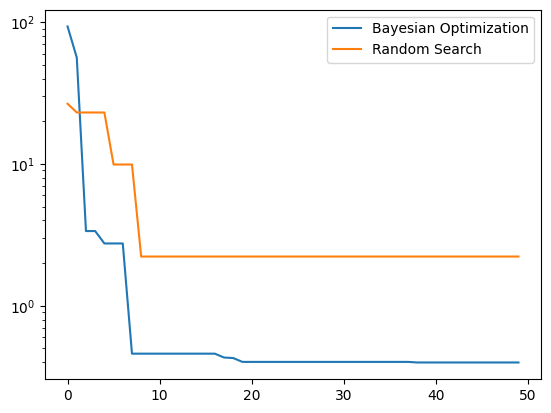

In [20]:

y_bo_min = torch.cummin(y_bo, dim=0).values
y_rs_min = torch.cummin(y_rs, dim=0).values

plt.plot(y_bo_min, label='Bayesian Optimization')
plt.plot(y_rs_min, label='Random Search')
plt.yscale('log')
plt.legend()
plt.show()


Now if you want to, you can reuse this BO loop for your other machine learning projects, just replace the black box function for whatever you want to optimize. :)

# Putting it all together

In this last step, we just provide some code to run and plot the BO and random sampling on all the different blackbox problems (initially we leave ANN out because it takes a long time to run).

Questions:
- What can we say about the results?


_Notes_:
- this can take a while. You might want to initially lower `N_REPEATS`



In [ ]:
from dataclasses import dataclass
from blackbox_problems import SVMWineQuality, SVMClassifierWineType, GradientBoostingWineQuality, ANNWineQuality


# Run each experiment 15 times
N_REPEATS    = 15
N_ITERATIONS = 50

# List the benchmarks
# (ANN is commented out because it is slow to run)
benchmarks = {
    "Branin":                    Branin(),
    "SVM Regressor":             SVMWineQuality(n_samples=500),
    "SVM Classifier\n(easy)":   SVMClassifierWineType(hard=False),
    "SVM Classifier\n(hard)":   SVMClassifierWineType(hard=True),
    "Gradient Boosting":         GradientBoostingWineQuality(n_samples=300),
    # "ANN":                       ANNWineQuality(n_samples=100),
}

# Define the output format of an experiment
@dataclass
class Results:
    """Output for M runs for a single benchmark. Curves have runs as rows and iterations as columns."""
    benchmark: str
    bo_curves: np.ndarray
    rs_curves: np.ndarray
    n_init: int



def run_experiments(benchmarks: dict[str, BlackBoxBase]) -> list[Results]:
    """Runs the experiments."""
    all_results = []
    for name, blackbox in benchmarks.items():

        bo_curves = []
        rs_curves = []

        for repeat in range(N_REPEATS):
            torch.manual_seed(repeat)
            print(f"{name.replace(chr(10), ' ')} — repeat {repeat + 1}/{N_REPEATS}")

            _, y_bo = bo_loop(blackbox, N_ITERATIONS)
            _, y_rs = rs_loop(blackbox, N_ITERATIONS)

            bo_curves.append(torch.cummin(y_bo, dim=0).values.squeeze().numpy())
            rs_curves.append(torch.cummin(y_rs, dim=0).values.squeeze().numpy())

        all_results.append(
            Results(
                benchmark=name,
                bo_curves=np.array(bo_curves),
                rs_curves=np.array(rs_curves),
                n_init = blackbox.dim + 1
            )
        )
    return all_results


def plot_results(all_results: list[Results]) -> None:
    """
    Plots the results.
    """
    n = len(all_results)
    _, axs = plt.subplots(1, n, figsize=(4.5 * n, 4), squeeze=False)
    axs = axs[0]

    for ax, results in zip(axs, all_results):
        iters = np.arange(1, results.bo_curves.shape[1] + 1)

        best_value = min(
            results.bo_curves.min(),
            results.rs_curves.min()
        )

        bo_regret = results.bo_curves - best_value + 1e-2
        rs_regret = results.rs_curves - best_value + 1e-2

        for curves, label, color, ls in [
            (bo_regret, "BO",            "steelblue", "-"),
            (rs_regret, "Random search", "tomato",    "--"),
        ]:
            mean = curves.mean(axis=0)
            std  = curves.std(axis=0)
            ax.plot(iters, mean, label=label, color=color, linewidth=2, linestyle=ls)
            ax.fill_between(iters, mean - std, mean + std, color=color, alpha=0.2)

        ax.axvline(results.n_init + 0.5, color="gray", linestyle=":", alpha=0.6,
                   label="init / BO start")
        ax.set_title(results.benchmark, fontsize=10)
        ax.set_xlabel("Evaluations")
        ax.set_ylabel("Best loss so far")
        ax.legend(fontsize=8)
        ax.set_yscale("log")

    plt.tight_layout()
    plt.savefig("benchmark_results.png", dpi=150)
    print("\nSaved benchmark_results.png")
    plt.show()


all_results = run_experiments(benchmarks)
plot_results(all_results)